In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
from comparing_slice_TCA_methods import *

In [22]:
data_truncated_array_SST = get_truncated_to_min_data_array(residual_activity_dict_SST)


In [4]:
data_truncated_array_EC = get_truncated_to_min_data_array(residual_activity_dict_EC)


In [23]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_SST, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_SST.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_SST.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Licks")

AttributeError: 'tuple' object has no attribute 'shape'

In [5]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")

In [6]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")

Loss: 0.8402883133357392 : 100%|██████████| 4000/4000 [16:55<00:00,  3.94it/s]


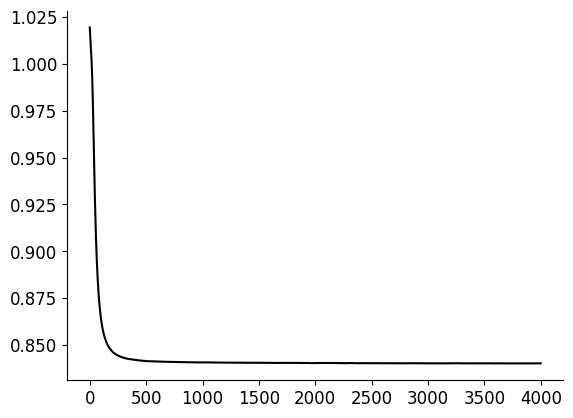

In [30]:
model_20_EC_raw_x00 = get_the_tca_model(residual_activity_dict_EC, components=(0,20,0))
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_EC_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_20_EC_raw_x00, f)



Loss: 0.3540542658425044 : 100%|██████████| 4000/4000 [01:34<00:00, 42.45it/s] 


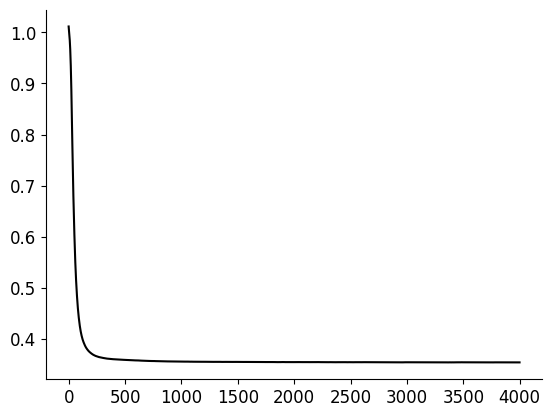

In [27]:
model_20_SST_raw_x00 = get_the_tca_model(residual_activity_dict_SST, components=(0,20,0))
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_SST_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_20_SST_raw_x00, f)

In [17]:



def get_animal_clean_dict_activity(filepath, use_final=True):
    with h5py.File(filepath, "r") as f:
        if use_final:
            animal_group = f["animals"]
        else:
            animal_group = f["animal"]

        shiftR_refs = animal_group["ShiftR"][:]
        shiftRunning_refs = animal_group["ShiftRunning"][:]

        if use_final:
            shiftL_refs = animal_group["ShiftL"][:]
        else:
            shiftL_refs = animal_group["ShiftLrate"][:]

        animal_clean_dict_activity = {}
        animal_trials_original = []
        animal_trials_clean = []

        animal_vel_dict = {}
        animal_lick_dict = {}

        trials_to_remove_local = []  # debug tracking for count == 105
        count = 0  # global cell counter (across animals)

        for animal_idx in range(len(shiftR_refs)):
            # ΔF: (cells, trials, time)
            delta_f = np.array(f[shiftR_refs[animal_idx][0]])
            animal_trials_original.append(delta_f.shape[1])

            # velocity & lick: raw (trials, time?) → transpose: (time, trials)
            vel = np.array(f[shiftRunning_refs[animal_idx][0]]).T
            lick = np.array(f[shiftL_refs[animal_idx][0]]).T

            # --- align trial counts across df / vel / lick ---
            n_df_trials = delta_f.shape[1]
            n_vel_trials = vel.shape[1]
            n_lick_trials = lick.shape[1]

            n_trials = min(n_df_trials, n_vel_trials, n_lick_trials)

            if (n_df_trials, n_vel_trials, n_lick_trials) != (n_trials,) * 3:
                delta_f = delta_f[:, :n_trials, :]
                vel = vel[:, :n_trials]
                lick = lick[:, :n_trials]

            # preallocate clean arrays
            vel_clean = np.empty_like(vel)
            lick_clean = np.empty_like(lick)
            delta_f_clean = np.empty_like(delta_f)

            # list of trials to drop for this animal (union across cells)
            trials_to_remove_list = []

            # special case: skip cell 0 for this animal
            if animal_idx == 22:
                valid_cells = range(1, delta_f.shape[0])
            else:
                valid_cells = range(delta_f.shape[0])

            # --- clean per cell / per trial ---
            for cell in valid_cells:
                # cell_data: (time, trials)
                cell_data = delta_f[cell, :, :].T

                for trial in range(cell_data.shape[1]):
                    trial_data = cell_data[:, trial]
                    vel_data_trial = vel[:, trial]
                    lick_data_trial = lick[:, trial]

                    nan_trial = np.any(np.isnan(trial_data))
                    nan_vel = np.any(np.isnan(vel_data_trial))

                    if nan_trial or nan_vel:
                        # decide: drop or interpolate based on runs of >=5 NaNs
                        too_many_nans = (
                            has_run_of_n_nans(trial_data, n=5)
                            or has_run_of_n_nans(vel_data_trial, n=5)
                        )

                        if too_many_nans:
                            # mark for removal (for all cells later)
                            if count == 105:
                                trials_to_remove_local.append(trial)
                            if trial not in trials_to_remove_list:
                                trials_to_remove_list.append(trial)
                        else:
                            # interpolate and keep this trial
                            clean_trial = interp_nans_1d(trial_data.copy())
                            delta_f_clean[cell, trial, :] = clean_trial

                            clean_vel = interp_nans_1d(vel_data_trial.copy())
                            vel_clean[:, trial] = clean_vel

                            clean_lick = interp_nans_1d(lick_data_trial.copy())
                            lick_clean[:, trial] = clean_lick
                    else:
                        # no NaNs anywhere: just copy
                        delta_f_clean[cell, trial, :] = trial_data
                        vel_clean[:, trial] = vel_data_trial
                        lick_clean[:, trial] = lick_data_trial

                count += 1  # increment per cell

            # --- drop bad trials across all cells for this animal ---
            trials_to_remove_array = np.array(trials_to_remove_list, dtype=int)

            if trials_to_remove_array.size > 0:
                mask = np.ones(delta_f_clean.shape[1], dtype=bool)
                mask[trials_to_remove_array] = False

                delta_f_clean = delta_f_clean[:, mask, :]
                vel_clean = vel_clean[:, mask]
                lick_clean = lick_clean[:, mask]

            animal_trials_clean.append(delta_f_clean.shape[1])

            # --- build per-cell dict with z-scoring ---
            cell_dict = {}
            for cell in valid_cells:
                cell_data = delta_f_clean[cell, :, :]  # (trials, time)

                mean = np.mean(cell_data)
                std = np.std(cell_data)

                if std == 0 or not np.isfinite(std):
                    # print(" -> zero or bad std for this cell, skipping")
                    continue

                cell_z = (cell_data - mean) / std  # (trials, time)
                cell_dict[f"cell_{cell+1}"] = cell_z.T  # (time, trials)

            animal_clean_dict_activity[f"animal_{animal_idx+1}"] = cell_dict
            animal_vel_dict[f"animal_{animal_idx+1}"] = {"Velocity": vel_clean}
            animal_lick_dict[f"animal_{animal_idx+1}"] = {"Licks": lick_clean}

        return (
            animal_clean_dict_activity,
            animal_vel_dict,
            animal_trials_original,
            animal_trials_clean,
            trials_to_remove_local,
            animal_lick_dict,
        )





def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array, min_val




def flatten_data(neuron_dict):
    flattened_data = {}
    for var in neuron_dict:
        flattened_data[var] = neuron_dict[var].flatten()
    return flattened_data

def fit_GLM(animal_factors_dict, neuron_activity, regression='linear', alphas=None):
    neuron_activity_flat = neuron_activity.flatten()
    flattened_data = flatten_data(animal_factors_dict)
    variable_names = [var for var in flattened_data]
    design_matrix_X = np.stack([flattened_data[var] for var in variable_names], axis=1)

    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)

    trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
    trialavg_predicted_activity = np.mean(neuron_predicted_activity.reshape(neuron_activity.shape), axis=1)
    pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0, 1]
    neuron_GLM_params = {}
    neuron_GLM_params['weights'] = {var: model.coef_[idx] for idx, var in enumerate(variable_names)}
    neuron_GLM_params['intercept'] = model.intercept_
    neuron_GLM_params['alpha'] = model.alpha_ if regression == 'ridge' else None
    neuron_GLM_params['l1_ratio'] = model.l1_ratio_ if regression == 'elastic' else None
    neuron_GLM_params['R2'] = model.score(design_matrix_X, neuron_activity_flat)
    neuron_GLM_params['pearson_R'] = pearson_R
    neuron_GLM_params['model'] = model
    return neuron_GLM_params, neuron_predicted_activity

def get_residual_activity_dict(activity_dict, predicted_activity_dict):
    residual_activity_dict = {}
    for animal in activity_dict:
        residual_activity_dict[animal] = {}
        for neuron in activity_dict[animal]:
            residual_activity_dict[animal][neuron] = activity_dict[animal][neuron] - predicted_activity_dict[animal][neuron]
    return residual_activity_dict

def fit_GLM_population(factors_dict, activity_dict, quintile=None, regression='ridge', alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}

    for animal in factors_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        animal_factors_dict = factors_dict[animal].copy()

        if quintile is not None:
            num_trials = animal_factors_dict['Activity'].shape[1]
            start_idx, end_idx = get_quintile_indices(num_trials, quintile)
            for var in animal_factors_dict:
                animal_factors_dict[var] = animal_factors_dict[var][:, start_idx:end_idx]

        for neuron_idx in activity_dict[animal]:
            neuron_activity = activity_dict[animal][neuron_idx]
            neuron_GLM_params, neuron_predicted_activity = fit_GLM(animal_factors_dict, neuron_activity, regression, alphas)
            GLM_params[animal][neuron_idx] = neuron_GLM_params
            predicted_activity_dict[animal][neuron_idx] = neuron_predicted_activity.reshape(activity_dict[animal][neuron_idx].shape)
                
    return GLM_params, predicted_activity_dict

def subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"]):
    filtered_factors_dict = {}
    for animal in factors_dict:
        filtered_factors_dict[animal] = {}
        for variable in variables_to_keep:
            filtered_factors_dict[animal][variable] = factors_dict[animal][variable]
    return filtered_factors_dict



def has_run_of_n_nans(trial_data, n=4):
    
    nan_mask = np.isnan(trial_data)
    if not np.any(nan_mask):
        return False
    
    conv = np.convolve(nan_mask.astype(int), np.ones(n, dtype=int), mode='valid')
    return np.any(conv >= n)


def interp_nans_1d(trial_data):
    x = np.arange(trial_data.size)
    nan_mask = np.isnan(trial_data)

    if not np.any(nan_mask):
        return trial_data

    if not np.any(~nan_mask):  # all NaNs
        return trial_data

    trial_data[nan_mask] = np.interp(x[nan_mask], x[~nan_mask], trial_data[~nan_mask])
    return trial_data



In [26]:
filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/SSTindivsomata_GLM.mat'

animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath, use_final=False)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_SST = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


In [29]:
filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/EC_GLM.mat'

animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath, use_final=False)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_EC = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


Loss: 0.4034574383094884 : 100%|██████████| 4000/4000 [01:46<00:00, 37.42it/s] 


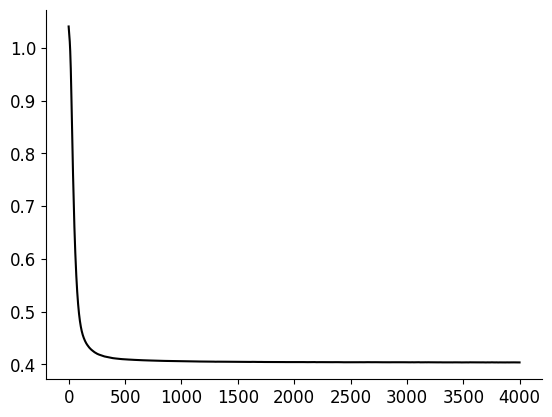

Loss: 0.35105656350159453 : 100%|██████████| 4000/4000 [01:42<00:00, 38.94it/s]


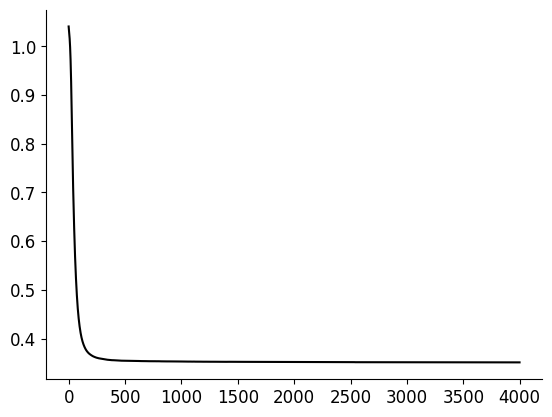

Loss: 0.043522347465508024 : 100%|██████████| 4000/4000 [01:54<00:00, 34.98it/s]


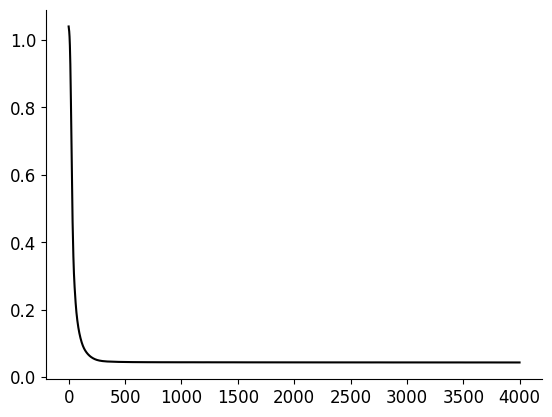

Loss: 0.35266420442558094 : 100%|██████████| 4000/4000 [01:51<00:00, 35.89it/s]


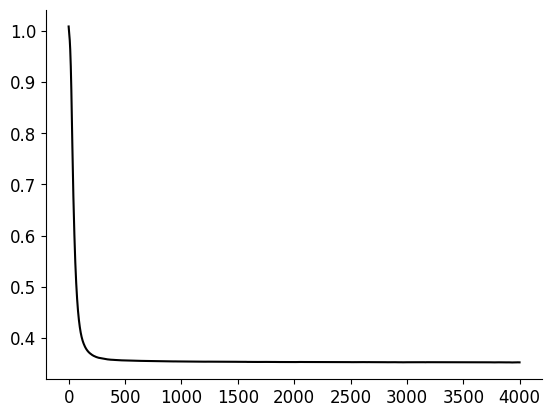

Loss: 0.4046510215109738 : 100%|██████████| 4000/4000 [02:21<00:00, 28.26it/s] 


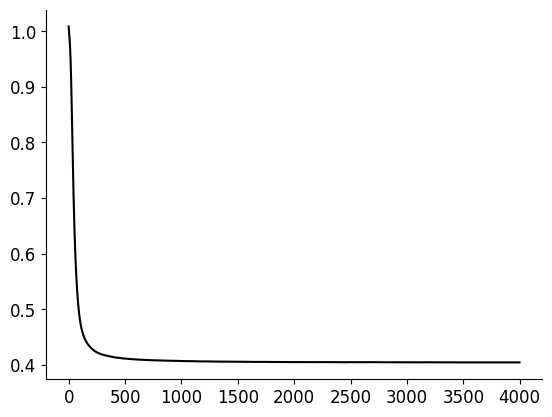

Loss: 0.04826753760308431 : 100%|██████████| 4000/4000 [02:29<00:00, 26.77it/s] 


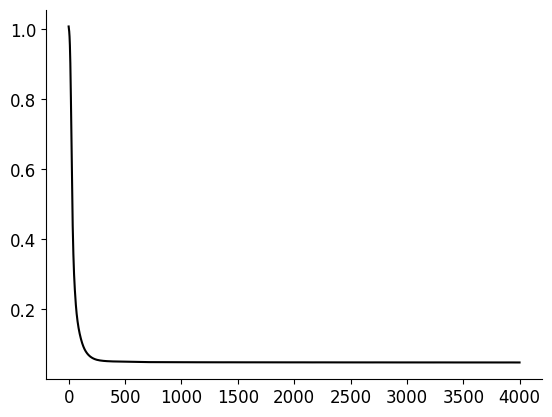

In [ ]:
# model_20_SST_raw_x00 = get_the_tca_model(activity_dict_SST, components=(20,0,0))
# model_20_SST_raw_0x0 = get_the_tca_model(activity_dict_SST, components=(0,20,0))
# model_20_SST_raw_00x = get_the_tca_model(activity_dict_SST, components=(0,0,20))

# model_20_SST_resid_0x0 = get_the_tca_model(residual_activity_dict_SST, components=(0,20,0))
# model_20_SST_resid_x00 = get_the_tca_model(residual_activity_dict_SST, components=(20,0,0))
# model_20_SST_resid_00x = get_the_tca_model(residual_activity_dict_SST, components=(0,0,20))

In [ ]:
# important_dict = {"model_20_SST_resid_0x0":model_20_SST_resid_0x0,
#                   "model_20_SST_resid_x00":model_20_SST_resid_x00,
#                   "model_20_SST_resid_00x":model_20_SST_resid_00x,
#                   "model_20_SST_raw_x00":model_20_SST_raw_x00,
#                   "model_20_SST_raw_0x0":model_20_SST_raw_0x0,
#                   "model_20_SST_raw_00x":model_20_SST_raw_00x
    
# }

# save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_SST.pkl"
# with open(save_path, 'wb') as f:
#     pickle.dump(important_dict, f)

In [5]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_SST.pkl"
with open(save_path, 'rb') as f:
    important_dict = pickle.load(f)

In [8]:
important_dict.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])

In [6]:
model_20_SST_resid_x00 = important_dict["model_20_SST_resid_x00"]
model_20_SST_resid_0x0 = important_dict["model_20_SST_resid_0x0"]
model_20_SST_resid_00x = important_dict["model_20_SST_resid_00x"]

model_20_SST_raw_x00 = important_dict["model_20_SST_raw_x00"]
model_20_SST_raw_0x0 = important_dict["model_20_SST_raw_0x0"]
model_20_SST_raw_00x = important_dict["model_20_SST_raw_00x"]

KeyError: 'model_20_SST_resid_x00'

In [ ]:
labels_cells_dict_all_K_SST_x00_raw = get_labels_all_different_Ks_single(model_20_SST_raw_x00, which_vectors=0)
labels_cells_dict_all_K_SST_0x0_raw = get_labels_all_different_Ks_single(model_20_SST_raw_0x0, which_vectors=1)
labels_cells_dict_all_K_SST_00x_raw = get_labels_all_different_Ks_single(model_20_SST_raw_00x, which_vectors=2)

labels_cells_dict_all_K_SST_x00_resid = get_labels_all_different_Ks_single(model_20_SST_resid_x00, which_vectors=0)
labels_cells_dict_all_K_SST_0x0_resid = get_labels_all_different_Ks_single(model_20_SST_resid_0x0, which_vectors=1)
labels_cells_dict_all_K_SST_00x_resid = get_labels_all_different_Ks_single(model_20_SST_resid_00x, which_vectors=2)

F.shape (20, 75, 50)  W.shape (20, 63)
X shape (latent×pos flat): (75, 1000)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)
F.shape (20, 63, 75)  W.shape (20, 50)
(75, 1260)
F.shape (20, 75, 50)  W.shape (20, 63)
X shape (latent×pos flat): (75, 1000)
F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)
F.shape (20, 63, 75)  W.shape (20, 50)
(75, 1260)


In [7]:
means_dict_cluster_00x_raw = plot_reconstructions(labels_cells_dict_all_K_SST_00x_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 00x Raw")
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_SST_0x0_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 0x0 Raw")
means_dict_cluster_x00_raw = plot_reconstructions(labels_cells_dict_all_K_SST_x00_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST x00 Raw")

############ different r list? 

means_dict_cluster_x00_resid = plot_reconstructions(labels_cells_dict_all_K_SST_x00_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST x00 Residuals")
means_dict_cluster_0x0_resid = plot_reconstructions(labels_cells_dict_all_K_SST_0x0_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 0x0 Residuals")
means_dict_cluster_00x_resid = plot_reconstructions(labels_cells_dict_all_K_SST_00x_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 00x Residuals")


NameError: name 'labels_cells_dict_all_K_SST_00x_raw' is not defined

In [10]:
count=0
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        count+=1
print(count)

75


F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 20 but corresponding boolean dimension is 75

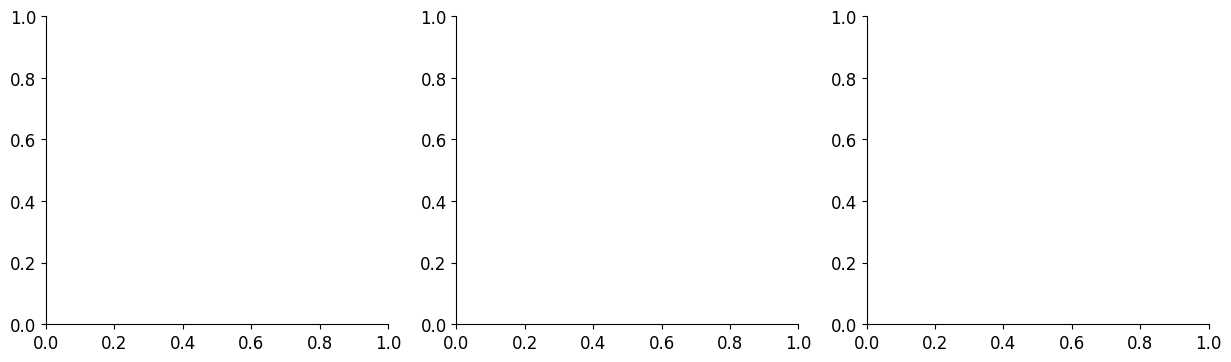

In [13]:
out = pca_cluster_viz(
    model_20_SST_raw_0x0,
    which_vectors=1,
    feature_space="loadings",     # or whatever you’re using in get_cell_features
    feature_mode="0x0",     # your existing arg
    n_cells_expected=75,         # fill with your expected count
    n_latents_expected=20,       # fill with your expected count
    n_components=3,
    num_clusters=2,               # <= set 2 if you want the LDA+orth trick; ≥3 uses LDA(2)
    title_prefix="SST 3D PCA")


In [9]:
cells_per_animal_dict = get_cells_per_animal_dict(activity_dict_SST)

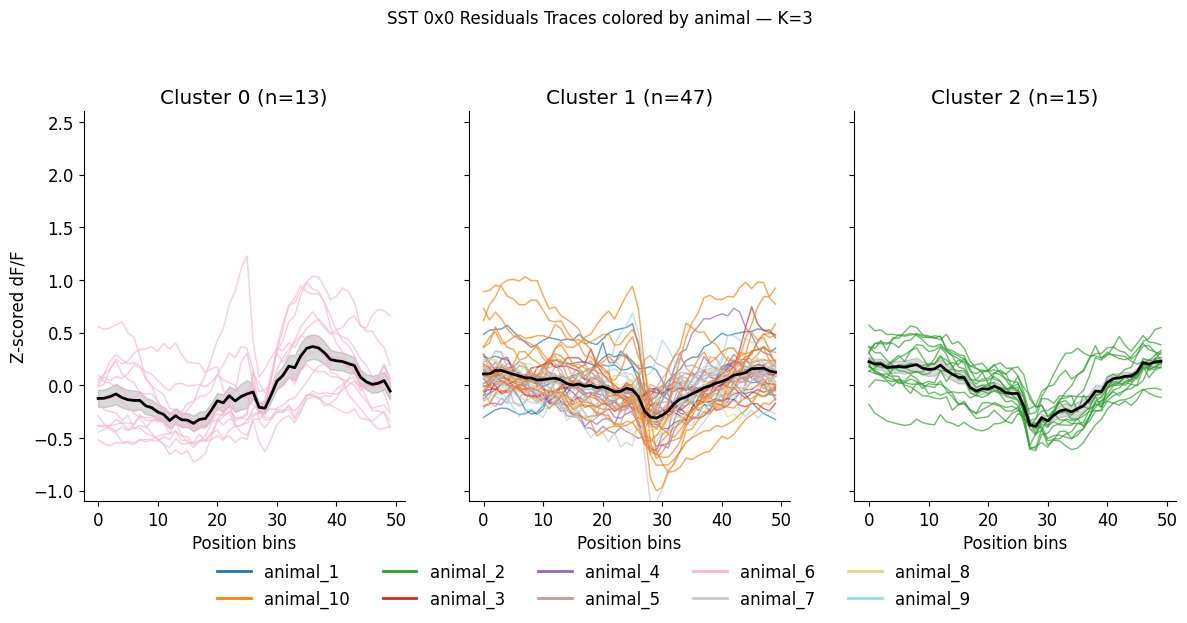

In [46]:
# plot_cluster_traces_by_animal(means_dict_cluster_0x0_raw,
#                               activity_dict_SST,
#                               cells_per_animal_dict,
#                               K=3,spacing=0.2,ncol=5,
#                               title_prefix="SST 0x0 Raw")

plot_cluster_traces_by_animal(means_dict_cluster_0x0_resid,
                              residual_activity_dict_SST,
                              cells_per_animal_dict,
                              K=3,
                              ncol=5, spacing=0.2,
                              title_prefix="SST 0x0 Residuals")

In [48]:
import os
p = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/spike_sim.pkl"
print(os.path.getsize(p), "bytes")
print(round(os.path.getsize(p)/1024**2, 2), "MB")

766218043 bytes
730.72 MB


In [ ]:
p = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/spike_sim.pkl"

with open(p, 'rb') as f:
    intermediates = pickle.load(f)
print(intermediates.keys())

AttributeError: Can't get attribute 'SimConfig' on <module '__main__'>

In [1]:
pca_cluster_viz(model_20_SST_raw_0x0, which_vectors=1, feature_space="loadings", feature_mode="0x0", n_cells_expected=73, n_latents_expected=20, n_components=3, num_clusters=2, title_prefix="NDNF 3D PCA")




NameError: name 'pca_cluster_viz' is not defined

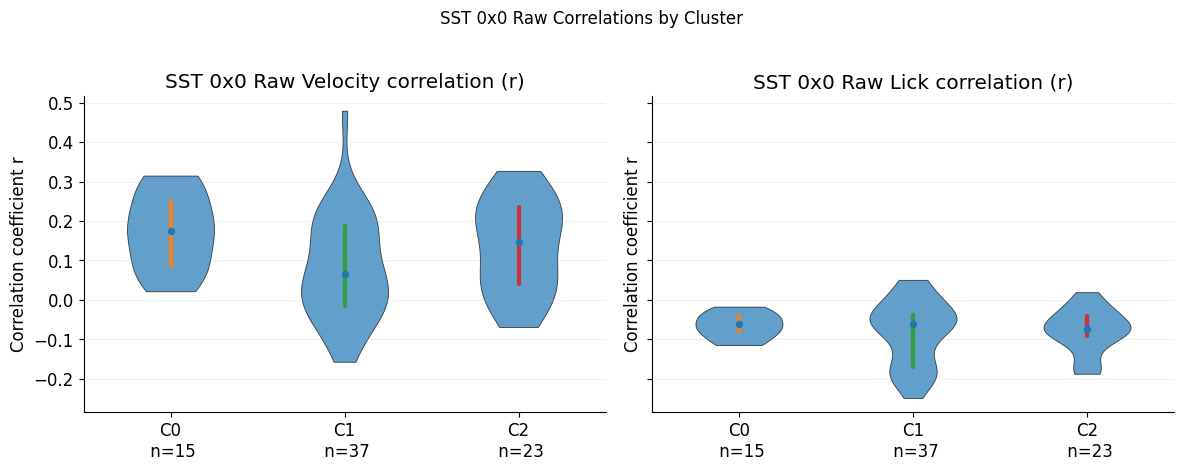

In [9]:
plot_violin_correlations_side_by_side(means_dict_cluster_0x0_raw, num_clusters=3, title="SST 0x0 Raw")


In [12]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

# def get_cp_dict(cell_SST_model_ranks20_contig_x00):
#     changepoints_dict = {}
#     for animal in cell_SST_model_ranks20_contig_x00[20]:
#         changepoints_cell_dict = {}
#         for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
#             labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
#             changepoints = np.where(np.diff(labels) != 0)[0]
#             changepoints_cell_dict[cell] = changepoints
#         changepoints_dict[animal] = changepoints_cell_dict

#     return changepoints_dict

# def get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00):
#     fixed_model_dict_NDNF_newest = {20:{}}
#     for animal in cell_NDNF_model_ranks20_contig_x00[20]:
#         if 17 < animal < 31:
#             fixed_model_dict_NDNF_newest[20][animal-18] = cell_NDNF_model_ranks20_contig_x00[20][animal]
#     return fixed_model_dict_NDNF_newest

fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

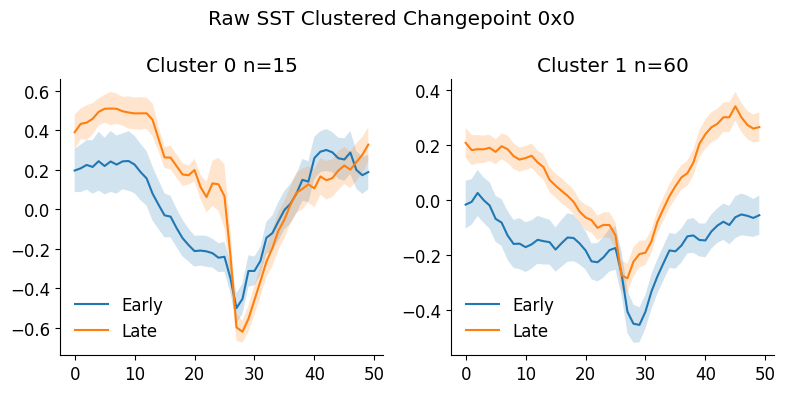

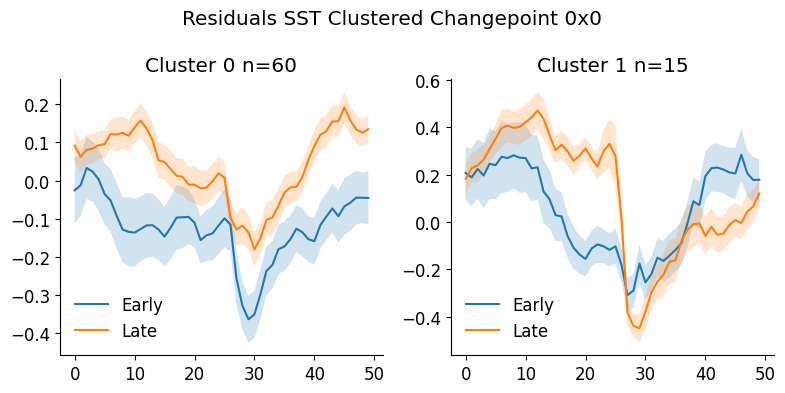

In [53]:
activity_early_array, activity_array_late = get_activity_cut_learn(activity_dict_SST, cp_dict_SST)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw SST Clustered Changepoint 0x0")

activity_early_array_resid, activity_array_late_resid = get_activity_cut_learn(residual_activity_dict_SST, cp_dict_SST)
plot_clustered_data_learn(means_dict_cluster_0x0_resid, activity_early_array_resid, activity_array_late_resid, K=2, title="Residuals SST Clustered Changepoint 0x0")



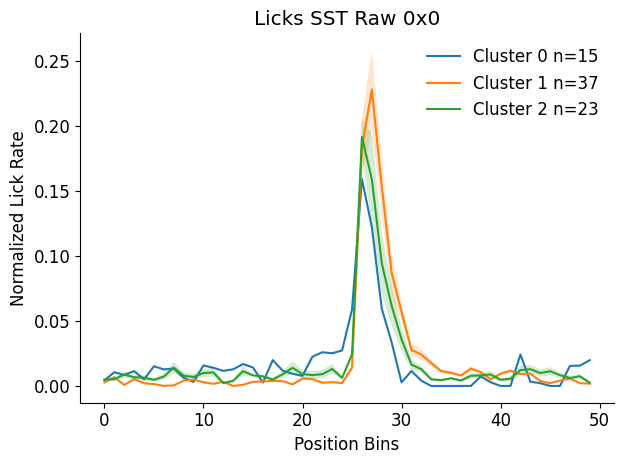

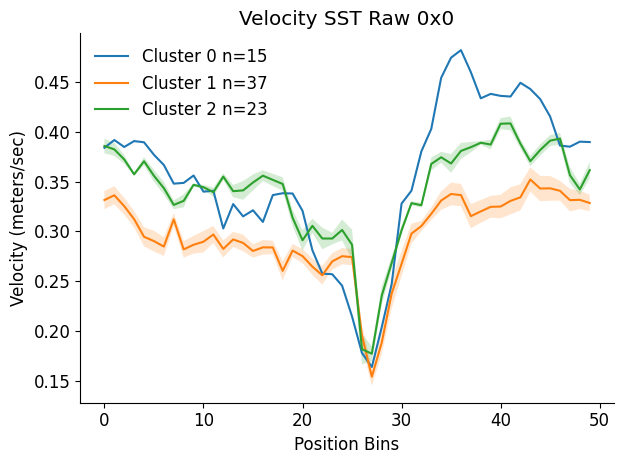

In [39]:
def plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=False, title=None):

    if use_vel:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["vel_data_sliced_dict"]
    else:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["lick_data_sliced_dict"]


    # fig, axs = plt.subplots(1,len(vel_data), figsize=(len(vel_data)*4, 4))
    for clust in vel_data:
        vel_array = vel_data[clust]
        trial_av_vel_array = np.mean(vel_array, axis=2)

        mean_over_cells = np.mean(trial_av_vel_array, axis=0)
        sem_over_cells = sem(trial_av_vel_array, axis=0)

        plt.plot(mean_over_cells, label=f"Cluster {clust} n={vel_array.shape[0]}")
        plt.fill_between(range(len(mean_over_cells)), mean_over_cells-sem_over_cells, mean_over_cells+sem_over_cells, alpha=0.2)
        # plt.title(f"Cluster {clust}")
        plt.xlabel("Position Bins")
        if use_vel:
            plt.ylabel(f"Velocity (meters/sec)")
        else:
            plt.ylabel(f"Normalized Lick Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=False, title="Licks SST Raw 0x0")
plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=True, title="Velocity SST Raw 0x0")